In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans

import glob
import os
import csv
import ast
import matplotlib.patheffects as path_effects
from matplotlib.ticker import PercentFormatter

from libpysal import weights

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    LinearSegmentedColormap,
    TwoSlopeNorm
)

### Read in source files 

In [2]:
# study area gdfs 
new_ea = gpd.read_file('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__KDee_Project_Git__/Geospatial_Analysis/Hotspot Analysis_Bivariate_Maps_Box_plots/new_ea.json')
new_data_study_area = gpd.read_file('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__KDee_Project_Git__/Geospatial_Analysis/Hotspot Analysis_Bivariate_Maps_Box_plots/new_data_study_area.json')

# PQR sites 
new_sites = gpd.read_file('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__KDee_Project_Git__/Geospatial_Analysis/Hotspot Analysis_Bivariate_Maps_Box_plots/new_sites.json')

# shapefile (all EAs)
filt_all_eas_dem_df = gpd.read_file('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__KDee_Project_Git__/Geospatial_Analysis/Hotspot Analysis_Bivariate_Maps_Box_plots/filt_all_eas_dem_df.json')

### Mapping of EAs and PQR sites 

In [3]:
ea_copy_pqr = new_ea.copy()
ea_copy_pqr = ea_copy_pqr[['ea_code9ch', 'geometry']]
merged_sites_pqr = gpd.sjoin(new_sites, ea_copy_pqr, how = 'inner', predicate = 'intersects')

merged_sites_pqr = merged_sites_pqr[['space_grouping', 'geometry', 'ea_code9ch']].reset_index(drop=True)

grouped_sites_df = merged_sites_pqr.groupby('ea_code9ch').agg({
    'space_grouping': lambda x: list(set(x)),  
})

grouped_sites_df = grouped_sites_df.rename(columns = {'space_grouping':'site_id'})

### 2021 Census Districts 

In [4]:
# read districts shapefile for plotting 
dist_2021 = gpd.read_file('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/__KDee_Project_Git__/Geospatial_Analysis/Hotspot Analysis_Bivariate_Maps_Box_plots/district_2021_census.geojson')

In [5]:
### Filter out Study Area Districts 

dist_2021 = gpd.sjoin(
    dist_2021, merged_sites_pqr.to_crs('EPSG:4326'), 
    how="inner", 
    predicate='contains' 
).reset_index(drop=True).drop(columns=['index_right'])

dist_2021 = dist_2021.drop_duplicates(['Name']).reset_index(drop=True)

# reproject to local CRS 
dist_2021_transformed = dist_2021.to_crs(merged_sites_pqr.crs)

district_gdf = dist_2021_transformed.copy()

### Revised EA shapefile  

In [6]:
filt_all_eas_dem_df_filt = gpd.sjoin(
    filt_all_eas_dem_df, dist_2021_transformed.drop(columns = ['ea_code9ch']), 
    how="inner", 
    predicate='intersects' 
).reset_index(drop=True)

## exclude additional EAs around the edges for basemap plotting 
additional_eas_to_exclude = [31400149, 31400142, 31400139, 31400134, 31400133, 30801173, 30801139, 30801138, 30801136, 30801063, 30801062, 30100656, 30100652, 30200407, 30200368, 30801041, 30801001, 30100689, 30200426]

filt_all_eas_dem_df_filt = filt_all_eas_dem_df_filt[
    ~filt_all_eas_dem_df_filt['ea_code9ch'].isin(additional_eas_to_exclude)
]

## 1) Logit Results Workflow 

### `update` this df if it changes 

In [7]:
converged_sensors_df = pd.read_csv('/home/kdonkor_umass_edu/Co-occurrence_Rev2/converged_sensors.csv').drop(columns = ['Unnamed: 0'])

sensor_list = converged_sensors_df['site_id'].unique().tolist()

In [8]:
len(sensor_list)

37

### Read sensor data file from a random day that has all sites & coordinate data 

In [9]:
df = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/2022_PQR_Data/2022/2022-05-01.csv')

df_filt = df[df['site_id'].isin(sensor_list)]

In [10]:
list_1 = df_filt['site_id'].unique().tolist()

len(list_1)

37

In [11]:
df_filt = df_filt[['time', 'respondent_id', 'site_latitude',
       'site_longitude', 'voltage', 'frequency', 'site_id']]


site_coords = (
    df_filt.groupby('site_id')[['site_latitude', 'site_longitude']]
      .first()
      .reset_index()
)

In [12]:
merged_df = converged_sensors_df.merge(
    site_coords,
    on='site_id',
    how='left'
)

merged_df = merged_df[['site_id', 'sensor_id', 'or_exposure', 'cesi_level', 'site_latitude', 'site_longitude']]

### convert to gdf 

In [13]:
import geopandas as gpd

# Convert dataframe to GeoDataFrame
sensor_gdf = gpd.GeoDataFrame(
    merged_df,
    geometry=gpd.points_from_xy(
        merged_df['site_longitude'],
        merged_df['site_latitude']
    ),
    crs='EPSG:4326'   # lat/lon CRS
)

# Convert to UTM Zone 30N
sensor_gdf = sensor_gdf.to_crs(epsg=32630)

In [14]:
sensor_gdf.head()

,site_id,sensor_id,or_exposure,cesi_level,site_latitude,site_longitude,geometry
0,4,08565208,2.602,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
1,4,6072cd14,0.790,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
2,4,d0e07e0f,3.167,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
3,4,e13978e1,2.194,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
4,19,11ed5164,0.610,Low,5.674785,-0.274575,POINT (801907.564 627965.231)


### Define x&y offsets, figsize, and x&y axis limits - so the spatial figures are more centered

In [15]:
common_x_ref_offset = 4     # km east if use_km=True
common_y_ref_offset = -1 

fig_size=(10, 8)

common_xlim = (-18, 18)
common_ylim = (-12, 22)

### hide y-axis; make points more central (ref should be same) 

In [16]:
def plot_site_or_distances_from_reference_binned(
    gdf,
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=True,
    figsize=(9, 7),

    # Sequential colors
    colors=None,

    # Binning
    n_bins=4,
    bins=None,
    bin_round=2,
    use_bins=False,

    # Plot styling
    point_size=70,
    annotate=False,
    cbar_label='Undervoltage Likelihood',
    cbar_labelpad=20,
    x_rotation=45,

    # Distance options
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,

    # Axis limits
    xlim=None,
    ylim=None,

    # Site collapsing
    collapse_sites=True,
    collapse_method='max',

    # Diverging OR cmap
    use_diverging_or_cmap=True,
    or_reference=1,

    # Colormap options
    cmap_name='RdBu_r',
    use_custom_colors=False,
    diverging_colors=None,

    # Normalization controls
    symmetric_cmap=True,
    vmin=None,
    vmax=None,

    # Layout
    colorbar_fraction=0.046,
    colorbar_pad=0.04,

    # Diagnostics
    diagnostics=True
):

    if colors is None:
        colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#cb181d']

    if diverging_colors is None:
        diverging_colors = [
            '#2166ac',  # below 1 = blue
            '#67a9cf',
            '#f7f7f7',
            '#f4a582',
            '#b2182b'   # above 1 = red
        ]

    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    # -------------------------------------------------
    # Clean invalid rows
    # -------------------------------------------------
    gdf = gdf.dropna(subset=['or_exposure', 'geometry']).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf['or_exposure'])].copy()
    gdf = gdf[gdf['or_exposure'] > 0].copy()

    if len(gdf) == 0:
        raise ValueError(
            "No valid rows left after removing NaN/inf/zero OR values or invalid geometries."
        )

    # -------------------------------------------------
    # Collapse multiple sensors per site
    # -------------------------------------------------
    if collapse_sites:

        if collapse_method == 'max':
            idx = gdf.groupby('site_id')['or_exposure'].idxmax()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'min':
            idx = gdf.groupby('site_id')['or_exposure'].idxmin()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs

            gdf = (
                gdf.groupby('site_id')
                   .agg(
                       or_exposure=('or_exposure', 'mean'),
                       cesi_level=('cesi_level', 'first'),
                       site_latitude=('site_latitude', 'first'),
                       site_longitude=('site_longitude', 'first'),
                       geometry=('geometry', 'first')
                   )
                   .reset_index()
            )

            gdf = gpd.GeoDataFrame(
                gdf,
                geometry='geometry',
                crs=original_crs
            )

        else:
            raise ValueError(
                "collapse_method must be 'max', 'min', or 'mean'"
            )

    # -------------------------------------------------
    # Point coordinates
    # -------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting'] = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    # -------------------------------------------------
    # Reference point
    # -------------------------------------------------
    if use_base_df:

        if base_gdf is None:
            raise ValueError(
                "base_gdf must be provided when use_base_df=True"
            )

        base_gdf = gpd.GeoDataFrame(
            base_gdf,
            geometry='geometry'
        ).copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_point = base_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    elif use_union_centroid:

        try:
            combined_geom = gdf.geometry.union_all()
        except Exception:
            combined_geom = gdf.geometry.unary_union

        ref_point = combined_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    else:

        if ref_easting is None:
            ref_easting = centroid_gdf['easting'].mean()

        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    # -------------------------------------------------
    # Apply reference offset
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000
    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # -------------------------------------------------
    # Distances
    # -------------------------------------------------
    centroid_gdf['x_distance'] = (
        centroid_gdf['easting'] - ref_easting
    )

    centroid_gdf['y_distance'] = (
        centroid_gdf['northing'] - ref_northing
    )

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East-West distance from reference (km)'
    else:
        x_label = 'East-West distance from reference (m)'

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print("\n--- Plot diagnostics ---")
        print("Rows after cleaning/collapse:", len(centroid_gdf))
        print("CRS:", centroid_gdf.crs)

        print("\nFinite checks:")
        print("x finite:", np.isfinite(centroid_gdf['x_distance']).all())
        print("y finite:", np.isfinite(centroid_gdf['y_distance']).all())
        print("OR finite:", np.isfinite(centroid_gdf['or_exposure']).all())
        print("ref_easting finite:", np.isfinite(ref_easting))
        print("ref_northing finite:", np.isfinite(ref_northing))
        print("x_ref_offset finite:", np.isfinite(x_ref_offset))
        print("y_ref_offset finite:", np.isfinite(y_ref_offset))

        print("\nRanges:")
        print(
            "x range:",
            centroid_gdf['x_distance'].min(),
            centroid_gdf['x_distance'].max()
        )
        print(
            "y range:",
            centroid_gdf['y_distance'].min(),
            centroid_gdf['y_distance'].max()
        )
        print(
            "OR range:",
            centroid_gdf['or_exposure'].min(),
            centroid_gdf['or_exposure'].max()
        )

        print("\nReference point:")
        print("ref_easting:", ref_easting)
        print("ref_northing:", ref_northing)

        print("\nAxis limits passed:")
        print("xlim:", xlim)
        print("ylim:", ylim)

        if xlim is not None:
            print("xlim finite:", all(np.isfinite(v) for v in xlim))

        if ylim is not None:
            print("ylim finite:", all(np.isfinite(v) for v in ylim))

        print("------------------------\n")

    # -------------------------------------------------
    # Data range
    # -------------------------------------------------
    or_min = centroid_gdf['or_exposure'].min()
    or_max = centroid_gdf['or_exposure'].max()

    # -------------------------------------------------
    # Determine plotting range
    # -------------------------------------------------
    if symmetric_cmap and vmin is None and vmax is None:

        distance_below = abs(or_reference - or_min)
        distance_above = abs(or_max - or_reference)

        max_distance = max(distance_below, distance_above)

        vmin_plot = or_reference - max_distance
        vmax_plot = or_reference + max_distance

        vmin_plot = max(vmin_plot, 0)

    else:

        vmin_plot = vmin if vmin is not None else or_min
        vmax_plot = vmax if vmax is not None else or_max

    if vmin_plot >= vmax_plot:
        raise ValueError(
            f"Invalid color scale: vmin_plot={vmin_plot}, vmax_plot={vmax_plot}"
        )

    # -------------------------------------------------
    # Colormap
    # -------------------------------------------------
    if use_diverging_or_cmap and not use_bins:

        if use_custom_colors:
            cmap = LinearSegmentedColormap.from_list(
                "custom_or_diverging_cmap",
                diverging_colors
            )
        else:
            cmap = plt.get_cmap(cmap_name)

        if vmin_plot < or_reference < vmax_plot:
            norm = TwoSlopeNorm(
                vmin=vmin_plot,
                vcenter=or_reference,
                vmax=vmax_plot
            )
        else:
            print(
                f"Warning: OR reference {or_reference} is outside plotting "
                f"range ({vmin_plot:.3f}, {vmax_plot:.3f}). "
                "Using regular normalization."
            )
            norm = None

    elif use_bins:

        cmap = ListedColormap(colors)

        if bins is None:
            bins = np.linspace(
                vmin_plot,
                vmax_plot,
                n_bins + 1
            )
            bins = np.round(bins, bin_round)
            bins = np.unique(bins)

        norm = BoundaryNorm(
            bins,
            cmap.N,
            clip=True
        )

    else:

        cmap = LinearSegmentedColormap.from_list(
            "smooth_custom_cmap",
            colors
        )

        norm = None

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['or_exposure'],
        cmap=cmap,
        norm=norm,
        s=point_size,
        alpha=0.9,
        vmin=None if norm is not None else vmin_plot,
        vmax=None if norm is not None else vmax_plot
    )

    ax.axhline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    ax.axvline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.text(
                row['x_distance'],
                row['y_distance'],
                str(row['site_id']),
                fontsize=8
            )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------
    cbar = plt.colorbar(
        sc,
        ax=ax,
        fraction=colorbar_fraction,
        pad=colorbar_pad
    )

    cbar.set_label(
        cbar_label,
        fontsize=13,
        fontweight='bold',
        labelpad=cbar_labelpad
    )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlabel(
        x_label,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    # Hide y-axis
    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    plt.tight_layout()
    plt.show()

    return centroid_gdf

In [17]:
def plot_site_or_distances_from_reference_binned(
    gdf,
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=True,
    figsize=(9, 7),

    # Sequential colors
    colors=None,

    # Binning
    n_bins=4,
    bins=None,
    bin_round=2,
    use_bins=False,

    # Plot styling
    point_size=70,
    annotate=False,
    cbar_label='Undervoltage Likelihood',
    cbar_labelpad=20,
    x_rotation=45,

    # Distance options
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,

    # Axis limits
    xlim=None,
    ylim=None,

    # Site collapsing
    collapse_sites=True,
    collapse_method='max',

    # Diverging OR cmap
    use_diverging_or_cmap=True,
    or_reference=1,

    # Colormap options
    cmap_name='RdBu_r',
    use_custom_colors=False,
    diverging_colors=None,

    # Normalization controls
    symmetric_cmap=True,
    vmin=None,
    vmax=None,

    # Layout
    colorbar_fraction=0.046,
    colorbar_pad=0.04,

    # Diagnostics
    diagnostics=True,

    save_path=None,
    dpi=300
):

    if colors is None:
        colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#cb181d']

    if diverging_colors is None:
        diverging_colors = [
            '#2166ac',  # below 1 = blue
            '#67a9cf',
            '#f7f7f7',
            '#f4a582',
            '#b2182b'   # above 1 = red
        ]

    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    # -------------------------------------------------
    # Clean invalid rows
    # -------------------------------------------------
    gdf = gdf.dropna(subset=['or_exposure', 'geometry']).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf['or_exposure'])].copy()
    gdf = gdf[gdf['or_exposure'] > 0].copy()

    if len(gdf) == 0:
        raise ValueError(
            "No valid rows left after removing NaN/inf/zero OR values or invalid geometries."
        )

    # -------------------------------------------------
    # Collapse multiple sensors per site
    # -------------------------------------------------
    if collapse_sites:

        if collapse_method == 'max':
            idx = gdf.groupby('site_id')['or_exposure'].idxmax()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'min':
            idx = gdf.groupby('site_id')['or_exposure'].idxmin()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs

            gdf = (
                gdf.groupby('site_id')
                   .agg(
                       or_exposure=('or_exposure', 'mean'),
                       cesi_level=('cesi_level', 'first'),
                       site_latitude=('site_latitude', 'first'),
                       site_longitude=('site_longitude', 'first'),
                       geometry=('geometry', 'first')
                   )
                   .reset_index()
            )

            gdf = gpd.GeoDataFrame(
                gdf,
                geometry='geometry',
                crs=original_crs
            )

        else:
            raise ValueError(
                "collapse_method must be 'max', 'min', or 'mean'"
            )

    # -------------------------------------------------
    # Point coordinates
    # -------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting'] = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    # -------------------------------------------------
    # Reference point
    # -------------------------------------------------
    if use_base_df:

        if base_gdf is None:
            raise ValueError(
                "base_gdf must be provided when use_base_df=True"
            )

        base_gdf = gpd.GeoDataFrame(
            base_gdf,
            geometry='geometry'
        ).copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_point = base_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    elif use_union_centroid:

        try:
            combined_geom = gdf.geometry.union_all()
        except Exception:
            combined_geom = gdf.geometry.unary_union

        ref_point = combined_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    else:

        if ref_easting is None:
            ref_easting = centroid_gdf['easting'].mean()

        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    # -------------------------------------------------
    # Apply reference offset
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000
    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # -------------------------------------------------
    # Distances
    # -------------------------------------------------
    centroid_gdf['x_distance'] = (
        centroid_gdf['easting'] - ref_easting
    )

    centroid_gdf['y_distance'] = (
        centroid_gdf['northing'] - ref_northing
    )

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East-West distance from reference (km)'
    else:
        x_label = 'East-West distance from reference (m)'

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print("\n--- Plot diagnostics ---")
        print("Rows after cleaning/collapse:", len(centroid_gdf))
        print("CRS:", centroid_gdf.crs)

        print("\nFinite checks:")
        print("x finite:", np.isfinite(centroid_gdf['x_distance']).all())
        print("y finite:", np.isfinite(centroid_gdf['y_distance']).all())
        print("OR finite:", np.isfinite(centroid_gdf['or_exposure']).all())
        print("ref_easting finite:", np.isfinite(ref_easting))
        print("ref_northing finite:", np.isfinite(ref_northing))
        print("x_ref_offset finite:", np.isfinite(x_ref_offset))
        print("y_ref_offset finite:", np.isfinite(y_ref_offset))

        print("\nRanges:")
        print(
            "x range:",
            centroid_gdf['x_distance'].min(),
            centroid_gdf['x_distance'].max()
        )
        print(
            "y range:",
            centroid_gdf['y_distance'].min(),
            centroid_gdf['y_distance'].max()
        )
        print(
            "OR range:",
            centroid_gdf['or_exposure'].min(),
            centroid_gdf['or_exposure'].max()
        )

        print("\nReference point:")
        print("ref_easting:", ref_easting)
        print("ref_northing:", ref_northing)

        print("\nAxis limits passed:")
        print("xlim:", xlim)
        print("ylim:", ylim)

        if xlim is not None:
            print("xlim finite:", all(np.isfinite(v) for v in xlim))

        if ylim is not None:
            print("ylim finite:", all(np.isfinite(v) for v in ylim))

        print("------------------------\n")

    # -------------------------------------------------
    # Data range
    # -------------------------------------------------
    or_min = centroid_gdf['or_exposure'].min()
    or_max = centroid_gdf['or_exposure'].max()

    # -------------------------------------------------
    # Determine plotting range
    # -------------------------------------------------
    if symmetric_cmap and vmin is None and vmax is None:

        distance_below = abs(or_reference - or_min)
        distance_above = abs(or_max - or_reference)

        max_distance = max(distance_below, distance_above)

        vmin_plot = or_reference - max_distance
        vmax_plot = or_reference + max_distance

        vmin_plot = max(vmin_plot, 0)

    else:

        vmin_plot = vmin if vmin is not None else or_min
        vmax_plot = vmax if vmax is not None else or_max

    if vmin_plot >= vmax_plot:
        raise ValueError(
            f"Invalid color scale: vmin_plot={vmin_plot}, vmax_plot={vmax_plot}"
        )

    # -------------------------------------------------
    # Colormap
    # -------------------------------------------------
    if use_diverging_or_cmap and not use_bins:

        if use_custom_colors:
            cmap = LinearSegmentedColormap.from_list(
                "custom_or_diverging_cmap",
                diverging_colors
            )
        else:
            cmap = plt.get_cmap(cmap_name)

        if vmin_plot < or_reference < vmax_plot:
            norm = TwoSlopeNorm(
                vmin=vmin_plot,
                vcenter=or_reference,
                vmax=vmax_plot
            )
        else:
            print(
                f"Warning: OR reference {or_reference} is outside plotting "
                f"range ({vmin_plot:.3f}, {vmax_plot:.3f}). "
                "Using regular normalization."
            )
            norm = None

    elif use_bins:

        cmap = ListedColormap(colors)

        if bins is None:
            bins = np.linspace(
                vmin_plot,
                vmax_plot,
                n_bins + 1
            )
            bins = np.round(bins, bin_round)
            bins = np.unique(bins)

        norm = BoundaryNorm(
            bins,
            cmap.N,
            clip=True
        )

    else:

        cmap = LinearSegmentedColormap.from_list(
            "smooth_custom_cmap",
            colors
        )

        norm = None

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['or_exposure'],
        cmap=cmap,
        norm=norm,
        s=point_size,
        alpha=0.9,
        vmin=None if norm is not None else vmin_plot,
        vmax=None if norm is not None else vmax_plot
    )

    ax.axhline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    ax.axvline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.text(
                row['x_distance'],
                row['y_distance'],
                str(row['site_id']),
                fontsize=8
            )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------
    cbar = plt.colorbar(
        sc,
        ax=ax,
        fraction=colorbar_fraction,
        pad=colorbar_pad
    )

    cbar.set_label(
        cbar_label,
        fontsize=13,
        fontweight='bold',
        labelpad=cbar_labelpad
    )

    # X formatting on colorbar ticks
    cbar.ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:g}X')
    )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlabel(
        x_label,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    # Hide y-axis
    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return centroid_gdf

### Mean collapsing 

In [18]:
def plot_site_or_distances_from_reference_binned(
    gdf,
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=True,
    figsize=(9, 7),

    # Sequential colors
    colors=None,

    # Binning
    n_bins=4,
    bins=None,
    bin_round=2,
    use_bins=False,

    # Plot styling
    point_size=70,
    annotate=False,
    cbar_label='Undervoltage Likelihood',
    cbar_labelpad=20,
    x_rotation=45,

    # Distance options
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,

    # Axis limits
    xlim=None,
    ylim=None,

    # Site collapsing
    collapse_sites=True,
    collapse_method='max',

    # Diverging OR cmap
    use_diverging_or_cmap=True,
    or_reference=1,

    # Colormap options
    cmap_name='RdBu_r',
    use_custom_colors=False,
    diverging_colors=None,

    # Normalization controls
    symmetric_cmap=True,
    vmin=None,
    vmax=None,

    # Colorbar ticks
    cbar_ticks=None,

    # Layout
    colorbar_fraction=0.046,
    colorbar_pad=0.04,

    # Diagnostics
    diagnostics=True,

    save_path=None,
    dpi=300
):

    if colors is None:
        colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#cb181d']

    if diverging_colors is None:
        diverging_colors = [
            '#2166ac',  # below 1 = blue
            '#67a9cf',
            '#f7f7f7',
            '#f4a582',
            '#b2182b'   # above 1 = red
        ]

    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    # -------------------------------------------------
    # Clean invalid rows
    # -------------------------------------------------
    gdf = gdf.dropna(subset=['or_exposure', 'geometry']).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf['or_exposure'])].copy()
    gdf = gdf[gdf['or_exposure'] > 0].copy()

    if len(gdf) == 0:
        raise ValueError(
            "No valid rows left after removing NaN/inf/zero OR values or invalid geometries."
        )

    # -------------------------------------------------
    # Collapse multiple sensors per site
    # -------------------------------------------------
    if collapse_sites:

        if collapse_method == 'max':
            idx = gdf.groupby('site_id')['or_exposure'].idxmax()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'min':
            idx = gdf.groupby('site_id')['or_exposure'].idxmin()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs

            gdf = (
                gdf.groupby('site_id')
                   .agg(
                       or_exposure=('or_exposure', 'mean'),
                       cesi_level=('cesi_level', 'first'),
                       site_latitude=('site_latitude', 'first'),
                       site_longitude=('site_longitude', 'first'),
                       geometry=('geometry', 'first')
                   )
                   .reset_index()
            )

            gdf = gpd.GeoDataFrame(
                gdf,
                geometry='geometry',
                crs=original_crs
            )

        else:
            raise ValueError(
                "collapse_method must be 'max', 'min', or 'mean'"
            )

    # -------------------------------------------------
    # Point coordinates
    # -------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting'] = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    # -------------------------------------------------
    # Reference point
    # -------------------------------------------------
    if use_base_df:

        if base_gdf is None:
            raise ValueError(
                "base_gdf must be provided when use_base_df=True"
            )

        base_gdf = gpd.GeoDataFrame(
            base_gdf,
            geometry='geometry'
        ).copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_point = base_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    elif use_union_centroid:

        try:
            combined_geom = gdf.geometry.union_all()
        except Exception:
            combined_geom = gdf.geometry.unary_union

        ref_point = combined_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    else:

        if ref_easting is None:
            ref_easting = centroid_gdf['easting'].mean()

        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    # -------------------------------------------------
    # Apply reference offset
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000
    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # -------------------------------------------------
    # Distances
    # -------------------------------------------------
    centroid_gdf['x_distance'] = (
        centroid_gdf['easting'] - ref_easting
    )

    centroid_gdf['y_distance'] = (
        centroid_gdf['northing'] - ref_northing
    )

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East-West distance from reference (km)'
    else:
        x_label = 'East-West distance from reference (m)'

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print("\n--- Plot diagnostics ---")
        print("Rows after cleaning/collapse:", len(centroid_gdf))
        print("CRS:", centroid_gdf.crs)

        print("\nFinite checks:")
        print("x finite:", np.isfinite(centroid_gdf['x_distance']).all())
        print("y finite:", np.isfinite(centroid_gdf['y_distance']).all())
        print("OR finite:", np.isfinite(centroid_gdf['or_exposure']).all())
        print("ref_easting finite:", np.isfinite(ref_easting))
        print("ref_northing finite:", np.isfinite(ref_northing))
        print("x_ref_offset finite:", np.isfinite(x_ref_offset))
        print("y_ref_offset finite:", np.isfinite(y_ref_offset))

        print("\nRanges:")
        print(
            "x range:",
            centroid_gdf['x_distance'].min(),
            centroid_gdf['x_distance'].max()
        )
        print(
            "y range:",
            centroid_gdf['y_distance'].min(),
            centroid_gdf['y_distance'].max()
        )
        print(
            "OR range:",
            centroid_gdf['or_exposure'].min(),
            centroid_gdf['or_exposure'].max()
        )

        print("\nReference point:")
        print("ref_easting:", ref_easting)
        print("ref_northing:", ref_northing)

        print("\nAxis limits passed:")
        print("xlim:", xlim)
        print("ylim:", ylim)

        if xlim is not None:
            print("xlim finite:", all(np.isfinite(v) for v in xlim))

        if ylim is not None:
            print("ylim finite:", all(np.isfinite(v) for v in ylim))

        print("------------------------\n")

    # -------------------------------------------------
    # Data range
    # -------------------------------------------------
    or_min = centroid_gdf['or_exposure'].min()
    or_max = centroid_gdf['or_exposure'].max()

    # -------------------------------------------------
    # Determine plotting range
    # -------------------------------------------------
    if symmetric_cmap and vmin is None and vmax is None:

        distance_below = abs(or_reference - or_min)
        distance_above = abs(or_max - or_reference)

        max_distance = max(distance_below, distance_above)

        vmin_plot = or_reference - max_distance
        vmax_plot = or_reference + max_distance

        vmin_plot = max(vmin_plot, 0)

    else:

        vmin_plot = vmin if vmin is not None else or_min
        vmax_plot = vmax if vmax is not None else or_max

    if vmin_plot >= vmax_plot:
        raise ValueError(
            f"Invalid color scale: vmin_plot={vmin_plot}, vmax_plot={vmax_plot}"
        )

    # -------------------------------------------------
    # Colormap
    # -------------------------------------------------
    if use_diverging_or_cmap and not use_bins:

        if use_custom_colors:
            cmap = LinearSegmentedColormap.from_list(
                "custom_or_diverging_cmap",
                diverging_colors
            )
        else:
            cmap = plt.get_cmap(cmap_name)

        if vmin_plot < or_reference < vmax_plot:
            norm = TwoSlopeNorm(
                vmin=vmin_plot,
                vcenter=or_reference,
                vmax=vmax_plot
            )
        else:
            print(
                f"Warning: OR reference {or_reference} is outside plotting "
                f"range ({vmin_plot:.3f}, {vmax_plot:.3f}). "
                "Using regular normalization."
            )
            norm = None

    elif use_bins:

        cmap = ListedColormap(colors)

        if bins is None:
            bins = np.linspace(
                vmin_plot,
                vmax_plot,
                n_bins + 1
            )
            bins = np.round(bins, bin_round)
            bins = np.unique(bins)

        norm = BoundaryNorm(
            bins,
            cmap.N,
            clip=True
        )

    else:

        cmap = LinearSegmentedColormap.from_list(
            "smooth_custom_cmap",
            colors
        )

        norm = None

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['or_exposure'],
        cmap=cmap,
        norm=norm,
        s=point_size,
        alpha=0.9,
        vmin=None if norm is not None else vmin_plot,
        vmax=None if norm is not None else vmax_plot
    )

    ax.axhline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    ax.axvline(
        0,
        linestyle='--',
        linewidth=1,
        color='black',
        alpha=0.6
    )

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.text(
                row['x_distance'],
                row['y_distance'],
                str(row['site_id']),
                fontsize=8
            )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------
    cbar = plt.colorbar(
        sc,
        ax=ax,
        fraction=colorbar_fraction,
        pad=colorbar_pad
    )

    cbar.set_label(
        cbar_label,
        fontsize=13,
        fontweight='bold',
        labelpad=cbar_labelpad
    )

    # Custom tick locations + X formatting
    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)

    cbar.ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:g}X')
    )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlabel(
        x_label,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    # Hide y-axis
    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return centroid_gdf

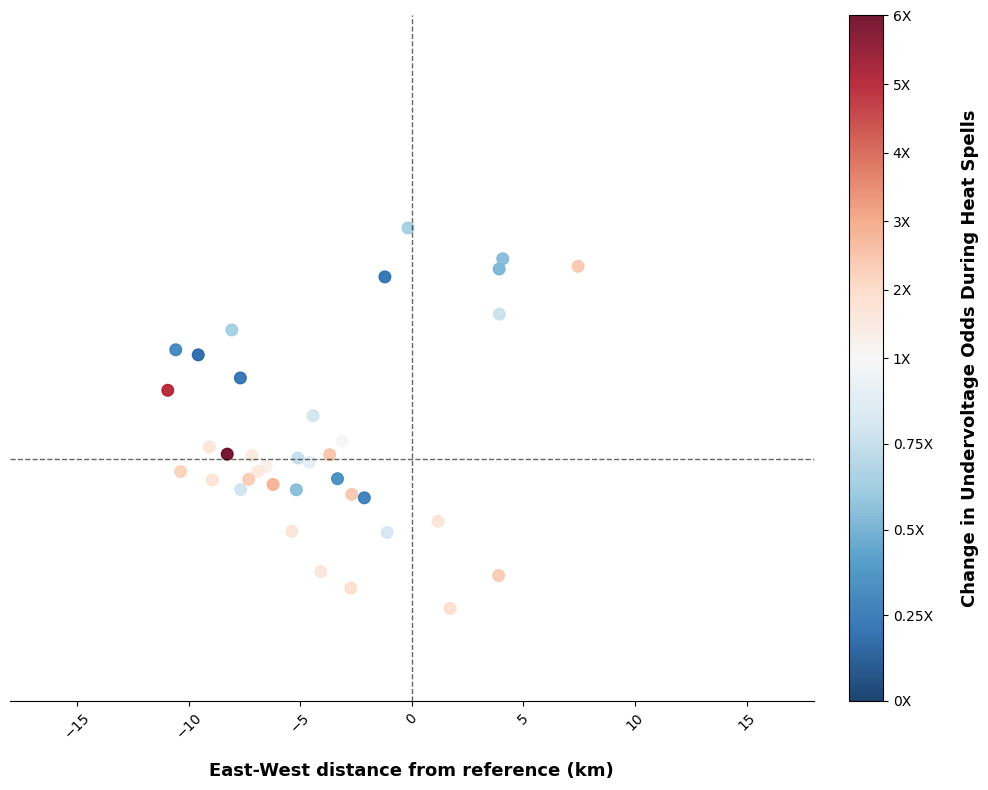

In [19]:
site_or_centroid = plot_site_or_distances_from_reference_binned(
    sensor_gdf,
    figsize=fig_size,
    cbar_label='Change in Undervoltage Odds During Heat Spells',
    use_bins=False,
    symmetric_cmap=False,
    collapse_method='mean',
    vmin=0,
    vmax=6,
    cbar_ticks=[0, 0.25, 0.5, 0.75, 1, 2, 3, 4, 5, 6],
    or_reference=1,
    cmap_name='RdBu_r',
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    save_path='spatial_logit_undervolt.png'
)

In [20]:
sensor_gdf[sensor_gdf['or_exposure']>1]

,site_id,sensor_id,or_exposure,cesi_level,site_latitude,site_longitude,geometry
0,4,08565208,2.602,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
2,4,d0e07e0f,3.167,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
3,4,e13978e1,2.194,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
8,24,ec67ce61,6.113,Low,5.619138,-0.276693,POINT (801701.548 621805.986)
10,46,32ff3446,1.513,High,5.566326,-0.239118,POINT (805894.97 615980.965)
11,46,84fae806,1.675,High,5.566326,-0.239118,POINT (805894.97 615980.965)
12,63,50e316ad,1.719,Low,5.607561,-0.282772,POINT (801033.603 620521.738)
13,108,b55263d7,1.687,Low,5.588628,-0.191662,POINT (811145.269 618473.994)
15,136,10360507,1.341,High,5.613596,-0.261036,POINT (803440.327 621200.797)
20,201,46d58d20,2.377,Low,5.600890,-0.226447,POINT (807281.918 619812.701)


In [21]:
sensor_gdf[sensor_gdf['or_exposure']<1]

,site_id,sensor_id,or_exposure,cesi_level,site_latitude,site_longitude,geometry
1,4,6072cd14,0.790,Low,5.611449,-0.295567,POINT (799613.029 620945.402)
4,19,11ed5164,0.610,Low,5.674785,-0.274575,POINT (801907.564 627965.231)
5,19,de7753a0,0.672,Low,5.674785,-0.274575,POINT (801907.564 627965.231)
6,20,69562a09,0.230,Low,5.698296,-0.212605,POINT (808764.997 630599.905)
7,23,530ad673,0.798,Low,5.636211,-0.241938,POINT (805545.89 623713.469)
9,39,a125ac7f,0.792,Low,5.603224,-0.271344,POINT (802302.831 620047.646)
14,122,0123d562,0.527,Low,5.701621,-0.166414,POINT (813883.949 630992.88)
16,169,8adc6485,0.555,High,5.603034,-0.248833,POINT (804798.813 620038.26)
17,175,3c77ee61,0.358,Low,5.607924,-0.232186,POINT (806641.907 620588.146)
18,183,0802489d,0.641,Low,5.720163,-0.203171,POINT (809799.131 633025.048)


## 2) OLS Results Workflow 

### check number of unique sites in the df 

In [22]:
ols_per_sensor = pd.read_csv('/home/kdonkor_umass_edu/Co-occurrence_Rev2/ols_per_sensor_results.csv').drop(columns=['Unnamed: 0'])
ols_sensor_list = ols_per_sensor['site_id'].unique().tolist()

In [23]:
len(ols_sensor_list)

211

### filter & get geometries from main `sample df` 

In [24]:
df = pd.read_csv('/work/pi_jtaneja_umass_edu/kdonkor_umass_edu/2022_PQR_Data/2022/2022-05-01.csv')
df_filt_ols = df[df['site_id'].isin(ols_sensor_list)]

In [25]:
df_filt_ols['site_id'].nunique()

211

In [26]:
df_filt_ols = df_filt_ols[['time', 'respondent_id', 'site_latitude',
       'site_longitude', 'voltage', 'frequency', 'site_id']]

site_coords_ols = (
    df_filt_ols.groupby('site_id')[['site_latitude', 'site_longitude']]
      .first()
      .reset_index()
)

merged_df_ols = ols_per_sensor.merge(
    site_coords_ols,
    on='site_id',
    how='left'
)

### convert to gdf 

In [27]:
import geopandas as gpd

# Convert dataframe to GeoDataFrame
sensor_ols_gdf = gpd.GeoDataFrame(
    merged_df_ols,
    geometry=gpd.points_from_xy(
        merged_df_ols['site_longitude'],
        merged_df_ols['site_latitude']
    ),
    crs='EPSG:4326'   # lat/lon CRS
)

# Convert to UTM Zone 30N
sensor_ols_gdf = sensor_ols_gdf.to_crs(epsg=32630)

In [28]:
sensor_ols_gdf.head()

,site_id,sensor_id,coef_Temp,sig_Temp,cesi_level,site_latitude,site_longitude,geometry
0,1,bb3ff846,-1.297078,True,Low,5.619831,-0.221795,POINT (807787.767 621911.325)
1,2,e2e26a75,-1.410181,True,Low,5.588561,-0.224331,POINT (807523.002 618449.386)
2,2,e39a61a6,-1.915402,True,Low,5.588561,-0.224331,POINT (807523.002 618449.386)
3,3,14618a70,-0.784692,True,Low,5.676189,-0.277559,POINT (801576 628119)
4,3,377f44ed,-1.503098,True,Low,5.676189,-0.277559,POINT (801576 628119)


### Just showing the negative values; hide the y-axis 

In [29]:
def plot_site_coef_distances_negative_only(
    gdf,
    value_col='coef_Temp',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    cbar_label='Voltage Sensitivity to Temperature (ΔV/°C)',
    cbar_labelpad=20,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    colorbar_fraction=0.046,
    colorbar_pad=0.04,
    vmin=None,
    vmax=None,
    diagnostics=False
):
    """
    Plots only negative coefficient values using a sequential red colormap.
    Darker red = more negative, lighter red = closer to zero.
    Y-axis is replaced by a solid vertical reference line at x=0.
    Only the x-axis (E-W distance) is shown.
    """

    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry']).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # -------------------------------------------------
    # Keep only negative values
    # -------------------------------------------------
    gdf = gdf[gdf[value_col] < 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No negative values found in column '{value_col}'.")

    # -------------------------------------------------
    # Collapse multiple sensors per site
    # -------------------------------------------------
    if collapse_sites:

        if collapse_method == 'max':
            idx = gdf.groupby('site_id')[value_col].idxmax()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'min':
            idx = gdf.groupby('site_id')[value_col].idxmin()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':

            original_crs = gdf.crs

            agg_dict = {
                value_col: (value_col, 'mean'),
                'cesi_level': ('cesi_level', 'first'),
                'site_latitude': ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry': ('geometry', 'first')
            }

            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = (
                gdf.groupby('site_id')
                   .agg(**agg_dict)
                   .reset_index()
            )

            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)

        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # -------------------------------------------------
    # Point coordinates
    # -------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting'] = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    # -------------------------------------------------
    # Reference point
    # -------------------------------------------------
    if use_base_df:

        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")

        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_point = base_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    elif use_union_centroid:

        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union

        ref_point = combined_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    else:

        if ref_easting is None:
            ref_easting = centroid_gdf['easting'].mean()

        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    # -------------------------------------------------
    # Apply offsets
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000
    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # -------------------------------------------------
    # Distances
    # -------------------------------------------------
    centroid_gdf['x_distance'] = (centroid_gdf['easting'] - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East-West distance from reference (km)'
    else:
        x_label = 'East-West distance from reference (m)'

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print("\n--- Plot diagnostics (negative-only) ---")
        print("Rows after negative filter:", len(centroid_gdf))
        print(f"{value_col} range:",
              centroid_gdf[value_col].min(),
              centroid_gdf[value_col].max())
        print("x range:",
              centroid_gdf['x_distance'].min(),
              centroid_gdf['x_distance'].max())
        print("y range:",
              centroid_gdf['y_distance'].min(),
              centroid_gdf['y_distance'].max())
        print("----------------------------------------\n")

    # -------------------------------------------------
    # Colormap: Reds_r
    # light pink = near zero, dark red = most negative
    # -------------------------------------------------
    cmap = plt.get_cmap('Reds_r')

    vmin_plot = vmin if vmin is not None else centroid_gdf[value_col].min()
    vmax_plot = vmax if vmax is not None else 0.0

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf[value_col],
        cmap=cmap,
        vmin=vmin_plot,
        vmax=vmax_plot,
        s=point_size,
        alpha=0.9
    )

    # Horizontal dashed reference line (N-S = 0)
    ax.axhline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    # Vertical solid line replaces the y-axis (E-W = 0)
    # ax.axvline(0, linestyle='-', linewidth=1.2, color='black', alpha=0.9)

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    # Remove all spines except bottom
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Remove y-axis entirely
    ax.yaxis.set_visible(False)

    # -------------------------------------------------
    # Optional annotations
    # -------------------------------------------------
    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.text(
                row['x_distance'],
                row['y_distance'],
                str(row['site_id']),
                fontsize=8
            )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------
    cbar = plt.colorbar(sc, ax=ax, fraction=colorbar_fraction, pad=colorbar_pad)
    cbar.set_label(
        cbar_label,
        fontsize=14,
        fontweight='bold',
        labelpad=cbar_labelpad
    )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    ax.spines['bottom'].set_visible(True)

    plt.tight_layout()
    plt.show()

    return centroid_gdf

In [30]:
def plot_site_coef_distances_negative_only(
    gdf,
    value_col='coef_Temp',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    cbar_label='Voltage Sensitivity to Temperature (ΔV/°C)',
    cbar_labelpad=20,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    colorbar_fraction=0.046,
    colorbar_pad=0.04,
    vmin=None,
    vmax=None,
    diagnostics=False,
    save_path=None,
    dpi=300
):
    """
    Plots only negative coefficient values using a sequential red colormap.
    Darker red = more negative, lighter red = closer to zero.
    Y-axis is replaced by a solid vertical reference line at x=0.
    Only the x-axis (E-W distance) is shown.
    """

    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry']).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # -------------------------------------------------
    # Keep only negative values
    # -------------------------------------------------
    gdf = gdf[gdf[value_col] < 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No negative values found in column '{value_col}'.")

    # -------------------------------------------------
    # Collapse multiple sensors per site
    # -------------------------------------------------
    if collapse_sites:

        if collapse_method == 'max':
            idx = gdf.groupby('site_id')[value_col].idxmax()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'min':
            idx = gdf.groupby('site_id')[value_col].idxmin()
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':

            original_crs = gdf.crs

            agg_dict = {
                value_col: (value_col, 'mean'),
                'cesi_level': ('cesi_level', 'first'),
                'site_latitude': ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry': ('geometry', 'first')
            }

            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = (
                gdf.groupby('site_id')
                   .agg(**agg_dict)
                   .reset_index()
            )

            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)

        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # -------------------------------------------------
    # Point coordinates
    # -------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting'] = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    # -------------------------------------------------
    # Reference point
    # -------------------------------------------------
    if use_base_df:

        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")

        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)

        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)

        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union

        ref_point = base_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    elif use_union_centroid:

        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union

        ref_point = combined_geom.centroid
        ref_easting = ref_point.x
        ref_northing = ref_point.y

    else:

        if ref_easting is None:
            ref_easting = centroid_gdf['easting'].mean()

        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    # -------------------------------------------------
    # Apply offsets
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000
    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # -------------------------------------------------
    # Distances
    # -------------------------------------------------
    centroid_gdf['x_distance'] = (centroid_gdf['easting'] - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East-West distance from reference (km)'
    else:
        x_label = 'East-West distance from reference (m)'

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print("\n--- Plot diagnostics (negative-only) ---")
        print("Rows after negative filter:", len(centroid_gdf))
        print(f"{value_col} range:",
              centroid_gdf[value_col].min(),
              centroid_gdf[value_col].max())
        print("x range:",
              centroid_gdf['x_distance'].min(),
              centroid_gdf['x_distance'].max())
        print("y range:",
              centroid_gdf['y_distance'].min(),
              centroid_gdf['y_distance'].max())
        print("----------------------------------------\n")

    # -------------------------------------------------
    # Colormap: Reds_r
    # light pink = near zero, dark red = most negative
    # -------------------------------------------------
    cmap = plt.get_cmap('Reds_r')

    vmin_plot = vmin if vmin is not None else centroid_gdf[value_col].min()
    vmax_plot = vmax if vmax is not None else 0.0

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf[value_col],
        cmap=cmap,
        vmin=vmin_plot,
        vmax=vmax_plot,
        s=point_size,
        alpha=0.9
    )

    # Horizontal dashed reference line (N-S = 0)
    # ax.axhline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    # Vertical dashed reference line (E-W = 0)
    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    # Remove all spines except bottom
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Remove y-axis entirely
    ax.yaxis.set_visible(False)

    # -------------------------------------------------
    # Optional annotations
    # -------------------------------------------------
    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.text(
                row['x_distance'],
                row['y_distance'],
                str(row['site_id']),
                fontsize=8
            )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------
    cbar = plt.colorbar(sc, ax=ax, fraction=colorbar_fraction, pad=colorbar_pad)
    cbar.set_label(
        cbar_label,
        fontsize=14,
        fontweight='bold',
        labelpad=cbar_labelpad
    )

    # -------------------------------------------------
    # Axes
    # -------------------------------------------------
    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    ax.spines['bottom'].set_visible(True)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return centroid_gdf

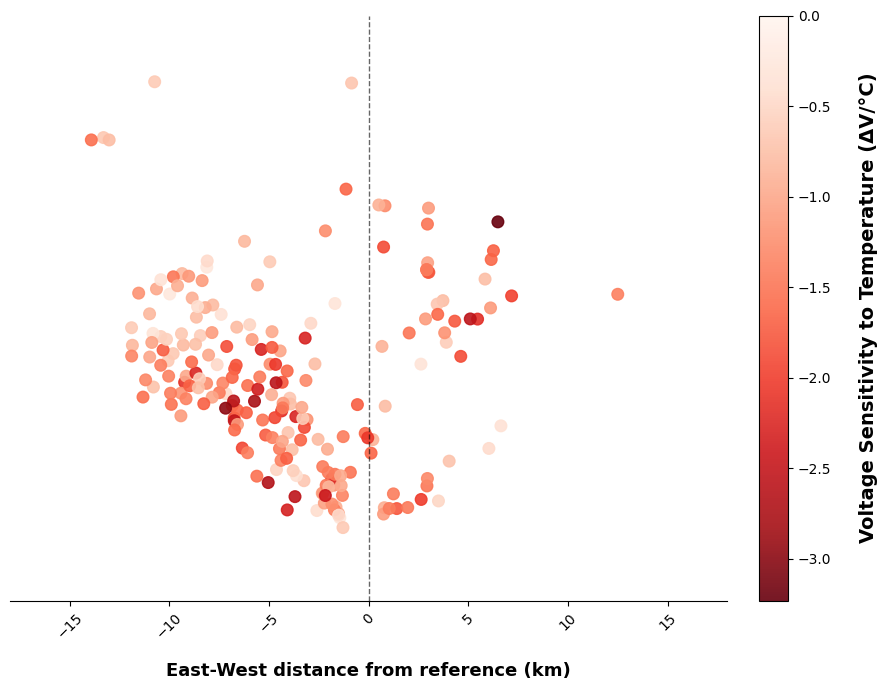

In [31]:
coef_temp_neg = plot_site_coef_distances_negative_only(
    sensor_ols_gdf,
    value_col='coef_Temp',
    use_union_centroid=True,
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False, 
    save_path = 'spatial_clustering_sensor_coefficients.png'
)

### Filter sensors - (coeff 0 or below; and classify `coef_Temp` as high or low based on median) 

In [32]:
# Filter to coef_Temp <= 0
sensor_ols_gdf_filtered = sensor_ols_gdf[sensor_ols_gdf['coef_Temp'] <= 0].copy()

# Calculate median of the filtered subset
median_coef = sensor_ols_gdf_filtered['coef_Temp'].median()

# Categorize: values <= median are more negative → "High" effect; above median → "Low" effect
sensor_ols_gdf_filtered['coef_Temp_category'] = sensor_ols_gdf_filtered['coef_Temp'].apply(
    lambda x: 'High' if x <= median_coef else 'Low'
)

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd


def plot_site_coef_bivariate(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Change in Voltage',
    legend_y_label='CESI',
    legend_coef_labels=('Low', 'High'),           # <-- new
    legend_cesi_labels=('Low', 'High'),           # <-- new
    legend_x_tick_rotation=0,                     # <-- new
    diagnostics=False
):
    """
    Plots coefficient values using a bivariate colour scheme.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colour mixing:
      - Coef axis : blue (#2166ac) → red  (#b2182b)
      - CESI axis : light (low)    → dark (high)

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    """

    BIVAR_COLORS = {
        ('Low',  'Low'):  '#a6c6e8',
        ('High', 'Low'):  '#f4a582',
        ('Low',  'High'): '#2166ac',
        ('High', 'High'): '#b2182b',
    }

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    
    gdf = gdf[gdf[value_col] <= 0].copy()

    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'E–W distance from reference (km)'
    else:
        x_label = 'E–W distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")
        print("----------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    # Build bbox from position anchor + cell size
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,   # total width  = 2 cells
        legend_cell_size * 2,   # total height = 2 cells
    )

    _add_bivariate_legend(
    ax,
    BIVAR_COLORS,
    bbox=legend_bbox,
    x_label=legend_x_label,
    y_label=legend_y_label,
    coef_labels=legend_coef_labels,
    cesi_labels=legend_cesi_labels,
    x_tick_rotation=legend_x_tick_rotation,
    )

    plt.tight_layout()
    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper
# ----------------------------------------------------------------------
def _add_bivariate_legend(ax, colors, bbox, x_label, y_label,
                          coef_labels, cesi_labels, x_tick_rotation=45):

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 7
    fs_tick  = 6.5

    # Axis labels
    axins.text(1.0, -0.55, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(-0.55, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels (coef ranges) — rotated
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, -0.1, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=x_tick_rotation,
                   transform=axins.transData)

    # Y-axis tick labels (cesi ranges)
    for row_idx, label in enumerate(cesi_labels):
        axins.text(-0.1, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

In [34]:
# coef_temp_neg = plot_site_coef_bivariate(
#     sensor_ols_gdf_filtered,
#     value_col='coef_Temp',
#     use_union_centroid=True,
#     use_km=True,
#     x_ref_offset=common_x_ref_offset,
#     y_ref_offset=common_y_ref_offset,
#     xlim=common_xlim,
#     ylim=common_ylim,
#     diagnostics=False,
#     legend_cell_size=0.10,
#     legend_pos=(0.92, 0.13),
# )

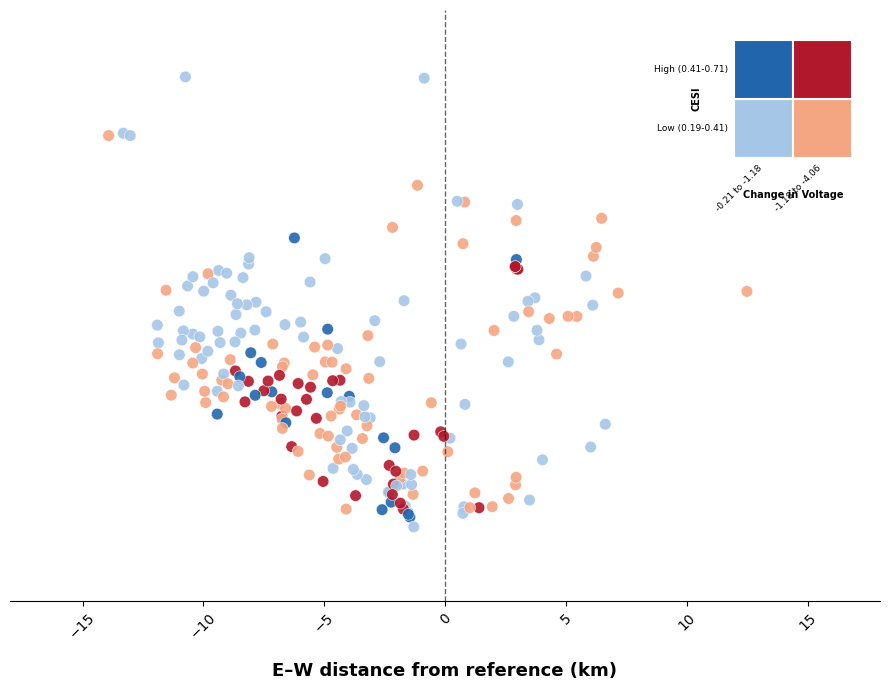

In [35]:
coef_temp_neg = plot_site_coef_bivariate(
    sensor_ols_gdf,
    value_col='coef_Temp',
    use_union_centroid=True,
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    legend_cell_size=0.10,
    legend_pos=(0.80, 0.75),
    legend_coef_labels=('-0.21 to -1.18', '-1.18 to -4.06'),
    legend_cesi_labels=('Low (0.19-0.41)', 'High (0.41-0.71)'),
    legend_x_tick_rotation=45,
)

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd


def plot_site_coef_bivariate(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Change in Voltage',
    legend_y_label='CESI',
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=0,
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,
    diagnostics=False
):
    """
    Plots coefficient values using a bivariate colour scheme.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colour mixing:
      - Coef axis : blue (#2166ac) → red  (#b2182b)
      - CESI axis : light (low)    → dark (high)

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    Only values <= 0 are plotted.
    """

    BIVAR_COLORS = {
        ('Low',  'Low'):  '#a6c6e8',
        ('High', 'Low'):  '#f4a582',
        ('Low',  'High'): '#2166ac',
        ('High', 'High'): '#b2182b',
    }

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # Keep only zero and negative values
    gdf = gdf[gdf[value_col] <= 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No values <= 0 found in column '{value_col}'.")

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'E–W distance from reference (km)'
    else:
        x_label = 'E–W distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")
        print("----------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2,
    )

    _add_bivariate_legend(
        ax,
        BIVAR_COLORS,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_tick_rotation=legend_x_tick_rotation,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset,
    )

    plt.tight_layout()
    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper
# ----------------------------------------------------------------------
def _add_bivariate_legend(
    ax, colors, bbox, x_label, y_label,
    coef_labels, cesi_labels,
    x_tick_rotation=0,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1,
):
    """
    Draws a compact 2×2 bivariate legend as an inset axes.

    Offset params (all in data coords of the inset axes, grid spans 0-2):
      x_label_offset : y position of the x-axis label  (more negative = further below)
      y_label_offset : x position of the y-axis label  (more negative = further left)
      x_tick_offset  : y position of x tick labels     (more negative = further below)
      y_tick_offset  : x position of y tick labels     (more negative = further left)
    """

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # row 0 = CESI Low (bottom), row 1 = CESI High (top)
    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 10
    fs_tick  = 8.5

    # Axis labels
    axins.text(1.0, x_label_offset, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(y_label_offset, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels (coef ranges)
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, x_tick_offset, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=x_tick_rotation,
                   rotation_mode='anchor',
                   transform=axins.transData)

    # Y-axis tick labels (cesi ranges)
    for row_idx, label in enumerate(cesi_labels):
        axins.text(y_tick_offset, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

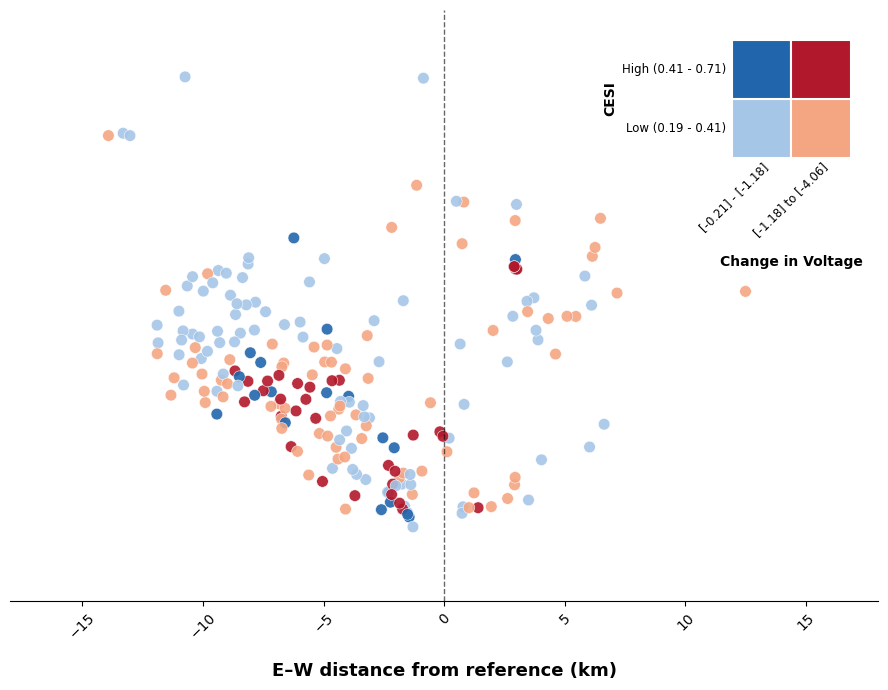

In [37]:
coef_temp_neg = plot_site_coef_bivariate(
    sensor_ols_gdf,
    value_col='coef_Temp',
    use_union_centroid=True,
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    legend_cell_size=0.10,
    legend_pos=(0.80, 0.75),
    legend_coef_labels=('[-0.21] - [-1.18]', '[-1.18] to [-4.06]'),
    # legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low (0.19 - 0.41)', 'High (0.41 - 0.71)'),
    legend_x_tick_rotation=45,
    legend_x_label_offset=-1.65,   # x-axis label distance below grid
    legend_y_label_offset=-1.95,   # y-axis label distance left of grid
    legend_x_tick_offset=-0.05,     # x tick labels distance below grid
    legend_y_tick_offset=-0.1,     # y tick labels distance left of grid
)

### Simpler Version 

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd


def plot_site_coef_bivariate(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Voltage Sensitivity',
    legend_y_label='CESI',
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=0,
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,
    diagnostics=False
):
    """
    Plots coefficient values using a bivariate colour scheme.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colour mixing:
      - Coef axis : blue (#2166ac) → red  (#b2182b)
      - CESI axis : light (low)    → dark (high)

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    Only values <= 0 are plotted.
    """

    BIVAR_COLORS = {
        ('Low',  'Low'):  '#a6c6e8',
        ('High', 'Low'):  '#f4a582',
        ('Low',  'High'): '#2166ac',
        ('High', 'High'): '#b2182b',
    }

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # Keep only zero and negative values
    gdf = gdf[gdf[value_col] <= 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No values <= 0 found in column '{value_col}'.")

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'E–W distance from reference (km)'
    else:
        x_label = 'E–W distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")
        print("----------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2,
    )

    _add_bivariate_legend(
        ax,
        BIVAR_COLORS,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_tick_rotation=legend_x_tick_rotation,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset,
    )

    plt.tight_layout()
    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper
# ----------------------------------------------------------------------
def _add_bivariate_legend(
    ax, colors, bbox, x_label, y_label,
    coef_labels, cesi_labels,
    x_tick_rotation=0,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1,
):
    """
    Draws a compact 2×2 bivariate legend as an inset axes.

    Offset params (all in data coords of the inset axes, grid spans 0-2):
      x_label_offset : y position of the x-axis label  (more negative = further below)
      y_label_offset : x position of the y-axis label  (more negative = further left)
      x_tick_offset  : y position of x tick labels     (more negative = further below)
      y_tick_offset  : x position of y tick labels     (more negative = further left)
    """

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # row 0 = CESI Low (bottom), row 1 = CESI High (top)
    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 10
    fs_tick  = 8.5

    # Axis labels
    axins.text(1.0, x_label_offset, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(y_label_offset, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels (coef ranges)
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, x_tick_offset, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=x_tick_rotation,
                   rotation_mode='anchor',
                   transform=axins.transData)

    # Y-axis tick labels (cesi ranges)
    for row_idx, label in enumerate(cesi_labels):
        axins.text(y_tick_offset, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

In [39]:
def plot_site_coef_bivariate(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Voltage Sensitivity',
    legend_y_label='CESI',
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=0,
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,
    diagnostics=False,
    save_path=None,
    dpi=300
):
    """
    Plots coefficient values using a bivariate colour scheme.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colour mixing:
      - Coef axis : blue (#2166ac) → red  (#b2182b)
      - CESI axis : light (low)    → dark (high)

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    Only values <= 0 are plotted.
    """

    BIVAR_COLORS = {
        ('Low',  'Low'):  '#a6c6e8',
        ('High', 'Low'):  '#f4a582',
        ('Low',  'High'): '#2166ac',
        ('High', 'High'): '#b2182b',
    }

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # Keep only zero and negative values
    gdf = gdf[gdf[value_col] <= 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No values <= 0 found in column '{value_col}'.")

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East–West distance from reference (km)'
    else:
        x_label = 'East–West distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")
        print("----------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2,
    )

    _add_bivariate_legend(
        ax,
        BIVAR_COLORS,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_tick_rotation=legend_x_tick_rotation,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset,
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper
# ----------------------------------------------------------------------
def _add_bivariate_legend(
    ax, colors, bbox, x_label, y_label,
    coef_labels, cesi_labels,
    x_tick_rotation=0,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1,
):
    """
    Draws a compact 2×2 bivariate legend as an inset axes.

    Offset params (all in data coords of the inset axes, grid spans 0-2):
      x_label_offset : y position of the x-axis label  (more negative = further below)
      y_label_offset : x position of the y-axis label  (more negative = further left)
      x_tick_offset  : y position of x tick labels     (more negative = further below)
      y_tick_offset  : x position of y tick labels     (more negative = further left)
    """

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # row 0 = CESI Low (bottom), row 1 = CESI High (top)
    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 10
    fs_tick  = 8.5

    # Axis labels
    axins.text(1.0, x_label_offset, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(y_label_offset, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels (coef ranges)
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, x_tick_offset, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=x_tick_rotation,
                   rotation_mode='anchor',
                   transform=axins.transData)

    # Y-axis tick labels (cesi ranges)
    for row_idx, label in enumerate(cesi_labels):
        axins.text(y_tick_offset, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

In [40]:
def plot_site_coef_bivariate(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Voltage Sensitivity',
    legend_y_label='CESI',
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=0,
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,
    diagnostics=True,
    save_path=None,
    dpi=300
):
    """
    Plots coefficient values using a bivariate colour scheme.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colour mixing:
      - Coef axis : blue (#2166ac) → red  (#b2182b)
      - CESI axis : light (low)    → dark (high)

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    Only values <= 0 are plotted.
    """

    BIVAR_COLORS = {
        ('Low',  'Low'):  '#a6c6e8',
        ('High', 'Low'):  '#f4a582',
        ('Low',  'High'): '#2166ac',
        ('High', 'High'): '#b2182b',
    }

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # Keep only zero and negative values
    gdf = gdf[gdf[value_col] <= 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No values <= 0 found in column '{value_col}'.")

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East–West distance from reference (km)'
    else:
        x_label = 'East–West distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")

        for cat in ['Low', 'High']:
            sub = centroid_gdf[centroid_gdf['coef_cat'] == cat][value_col]
            if len(sub) > 0:
                print(
                    f"\n'{cat}' sensitivity range: "
                    f"[{sub.min():.4f}, {sub.max():.4f}]  "
                    f"(n={len(sub)})"
                )
            else:
                print(f"\n'{cat}' sensitivity range: no rows")

        print("----------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2,
    )

    _add_bivariate_legend(
        ax,
        BIVAR_COLORS,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_tick_rotation=legend_x_tick_rotation,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset,
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper
# ----------------------------------------------------------------------
def _add_bivariate_legend(
    ax, colors, bbox, x_label, y_label,
    coef_labels, cesi_labels,
    x_tick_rotation=0,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1,
):
    """
    Draws a compact 2×2 bivariate legend as an inset axes.

    Offset params (all in data coords of the inset axes, grid spans 0-2):
      x_label_offset : y position of the x-axis label  (more negative = further below)
      y_label_offset : x position of the y-axis label  (more negative = further left)
      x_tick_offset  : y position of x tick labels     (more negative = further below)
      y_tick_offset  : x position of y tick labels     (more negative = further left)
    """

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # row 0 = CESI Low (bottom), row 1 = CESI High (top)
    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 10
    fs_tick  = 8.5

    # Axis labels
    axins.text(1.0, x_label_offset, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(y_label_offset, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels (coef ranges)
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, x_tick_offset, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=x_tick_rotation,
                   rotation_mode='anchor',
                   transform=axins.transData)

    # Y-axis tick labels (cesi ranges)
    for row_idx, label in enumerate(cesi_labels):
        axins.text(y_tick_offset, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

### filtering only the negative ones 

In [41]:
sensor_ols_gdf_filt = sensor_ols_gdf[sensor_ols_gdf['coef_Temp']<=0]

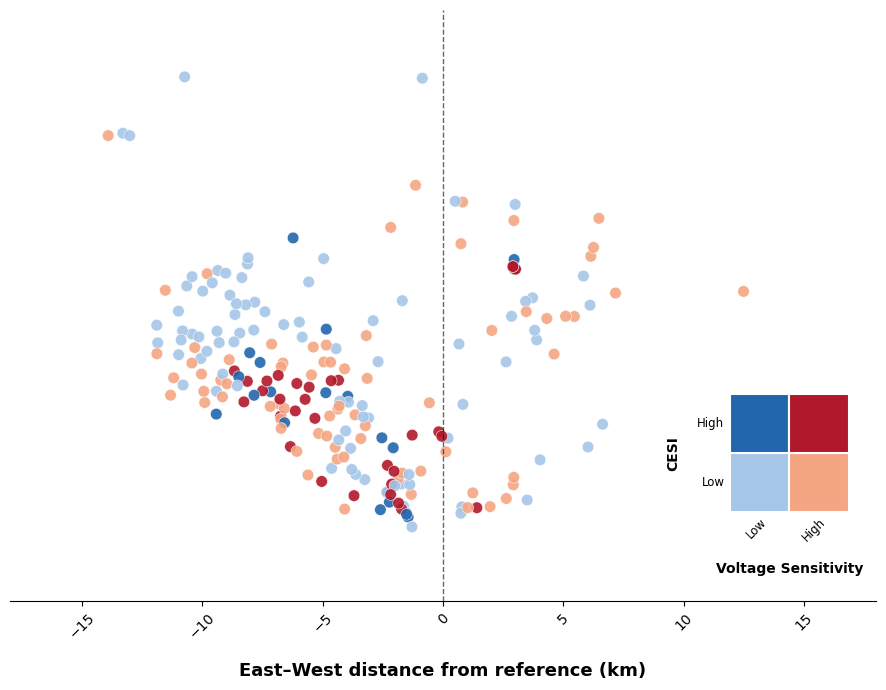

In [42]:
coef_temp_neg = plot_site_coef_bivariate(
    sensor_ols_gdf_filt,
    value_col='coef_Temp',
    use_union_centroid=True,
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    legend_cell_size=0.10,
    legend_pos=(0.80, 0.15),
    legend_coef_labels=('Low', 'High'),
    # legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=45,
    legend_x_label_offset=-0.85,   # x-axis label distance below grid
    legend_y_label_offset=-0.85,   # y-axis label distance left of grid
    legend_x_tick_offset=-0.05,     # x tick labels distance below grid
    legend_y_tick_offset=-0.1,     # y tick labels distance left of grid
    # save_path='spatial_clustering_bivar.png'
)

In [43]:
# Sensor-level (no collapse)
sensor_ols_gdf_filt.groupby('cesi_level')['coef_Temp'].describe()

,count,mean,std,min,25%,50%,75%,max
cesi_level,,,,,,,,
High,91.0,-1.487401,0.649318,-3.037652,-1.775405,-1.418966,-1.064821,-0.250613
Low,280.0,-1.172786,0.625969,-4.062061,-1.556312,-1.022411,-0.694108,-0.211809


In [44]:
# Site-level (after collapse)
site_level_df = (
    sensor_ols_gdf_filt
    .groupby('site_id')
    .agg(
        coef_Temp=('coef_Temp', 'mean'),
        cesi_level=('cesi_level', 'first')
    )
    .reset_index()
)

site_level_df.groupby('cesi_level')['coef_Temp'].describe()

,count,mean,std,min,25%,50%,75%,max
cesi_level,,,,,,,,
High,51.0,-1.439055,0.638108,-2.786919,-1.769011,-1.436133,-0.988904,-0.293771
Low,159.0,-1.204827,0.565664,-3.232737,-1.559377,-1.129975,-0.761024,-0.257025


### trying different colors 

In [47]:
def plot_site_coef_bivariate(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- quadrant colors ---
    quadrant_colors=None,   # dict mapping ('Low'/'High' coef, 'Low'/'High' cesi) -> color
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Voltage Sensitivity',
    legend_y_label='CESI',
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=0,
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,
    diagnostics=True,
    save_path=None,
    dpi=300
):
    """
    Plots coefficient values using a bivariate colour scheme.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colours are fully customizable via `quadrant_colors`, a dict keyed by
    (coef_cat, cesi_cat) tuples, e.g.:

        quadrant_colors = {
            ('Low',  'Low'):  '#a6c6e8',
            ('High', 'Low'):  '#f4a582',
            ('Low',  'High'): '#2166ac',
            ('High', 'High'): '#b2182b',
        }

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    Only values <= 0 are plotted.
    """

    DEFAULT_QUADRANT_COLORS = {
        ('Low',  'Low'):  '#a6c6e8',
        ('High', 'Low'):  '#f4a582',
        ('Low',  'High'): '#2166ac',
        ('High', 'High'): '#b2182b',
    }

    if quadrant_colors is None:
        quadrant_colors = DEFAULT_QUADRANT_COLORS
    else:
        # Fill in any missing keys with defaults
        merged = DEFAULT_QUADRANT_COLORS.copy()
        merged.update(quadrant_colors)
        quadrant_colors = merged

    BIVAR_COLORS = quadrant_colors

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # Keep only zero and negative values
    gdf = gdf[gdf[value_col] <= 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No values <= 0 found in column '{value_col}'.")

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'East–West distance from reference (km)'
    else:
        x_label = 'East–West distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")

        for cat in ['Low', 'High']:
            sub = centroid_gdf[centroid_gdf['coef_cat'] == cat][value_col]
            if len(sub) > 0:
                print(
                    f"\n'{cat}' sensitivity range: "
                    f"[{sub.min():.4f}, {sub.max():.4f}]  "
                    f"(n={len(sub)})"
                )
            else:
                print(f"\n'{cat}' sensitivity range: no rows")

        print("----------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2,
    )

    _add_bivariate_legend(
        ax,
        BIVAR_COLORS,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_tick_rotation=legend_x_tick_rotation,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset,
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper
# ----------------------------------------------------------------------
def _add_bivariate_legend(
    ax, colors, bbox, x_label, y_label,
    coef_labels, cesi_labels,
    x_tick_rotation=0,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1,
):
    """
    Draws a compact 2×2 bivariate legend as an inset axes.

    Offset params (all in data coords of the inset axes, grid spans 0-2):
      x_label_offset : y position of the x-axis label  (more negative = further below)
      y_label_offset : x position of the y-axis label  (more negative = further left)
      x_tick_offset  : y position of x tick labels     (more negative = further below)
      y_tick_offset  : x position of y tick labels     (more negative = further left)
    """

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # row 0 = CESI Low (bottom), row 1 = CESI High (top)
    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 10
    fs_tick  = 8.5

    # Axis labels
    axins.text(1.0, x_label_offset, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(y_label_offset, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels (coef ranges)
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, x_tick_offset, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=x_tick_rotation,
                   rotation_mode='anchor',
                   transform=axins.transData)

    # Y-axis tick labels (cesi ranges)
    for row_idx, label in enumerate(cesi_labels):
        axins.text(y_tick_offset, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

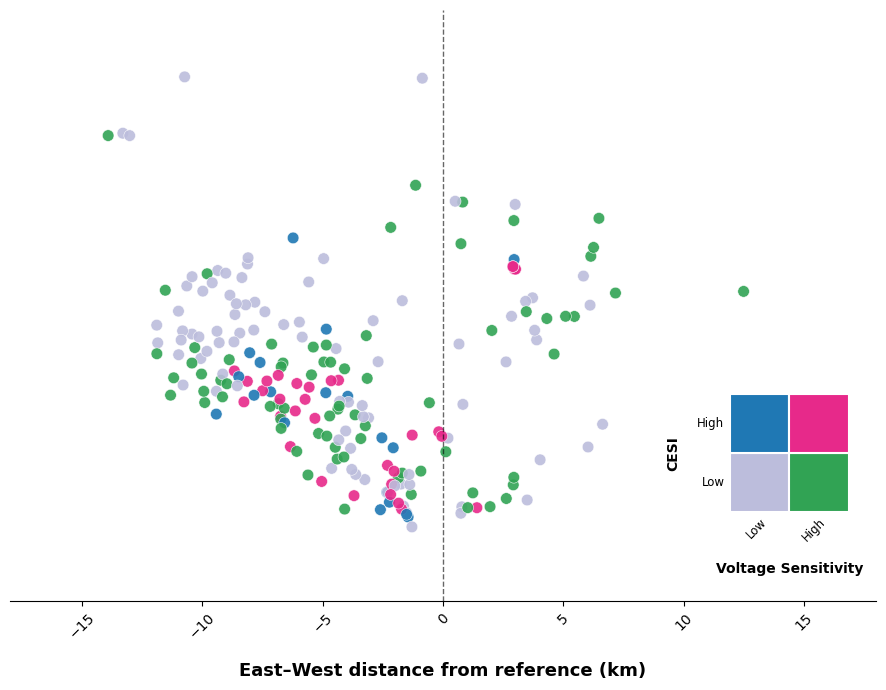

In [78]:
custom_colors = {
    ('Low',  'Low'):  '#bcbddc',
    ('High', 'Low'):  '#31a354',  # pink/magenta
    ('Low',  'High'): '#1f78b4',  # steel blue
    ('High', 'High'): '#e7298a',
}

coef_temp_neg = plot_site_coef_bivariate(
    sensor_ols_gdf_filt,
    value_col='coef_Temp',
    quadrant_colors=custom_colors,
    use_union_centroid=True,
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    legend_cell_size=0.10,
    legend_pos=(0.80, 0.15),
    legend_coef_labels=('Low', 'High'),
    legend_cesi_labels=('Low', 'High'),
    legend_x_tick_rotation=45,
    legend_x_label_offset=-0.85,
    legend_y_label_offset=-0.85,
    legend_x_tick_offset=-0.05,
    legend_y_tick_offset=-0.1,
    save_path='spatial_clustering_bivar_v1.png'
)

In [76]:
# ('High', 'High'): '#54278f',  --> this purple was nice 

# ('High', 'High'): '#08306b',  # dark navy 

# ('Low',  'Low'):  '#cccccc',  # gray

### Multi-line version 

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd


def plot_site_coef_bivariate_v2(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Change in Voltage',
    legend_y_label='CESI',
    legend_coef_labels=('Low\n', 'High\n'),
    legend_cesi_labels=('Low\n', 'High\n'),
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,
    diagnostics=False
):
    """
    Version 2 of the bivariate plot.

    Same as v1 but the 2x2 legend uses two-line tick labels
    (e.g. 'Low\\n[-0.21] - [-1.18]') with no rotation,
    centred under/beside each cell.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colour mixing:
      - Coef axis : blue (#2166ac) → red  (#b2182b)
      - CESI axis : light (low)    → dark (high)

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    Only values <= 0 are plotted.
    """

    BIVAR_COLORS = {
        ('Low',  'Low'):  '#a6c6e8',
        ('High', 'Low'):  '#f4a582',
        ('Low',  'High'): '#2166ac',
        ('High', 'High'): '#b2182b',
    }

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # Keep only zero and negative values
    gdf = gdf[gdf[value_col] <= 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No values <= 0 found in column '{value_col}'.")

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'E–W distance from reference (km)'
    else:
        x_label = 'E–W distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics (v2) ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")
        print("---------------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2,
    )

    _add_bivariate_legend_v2(
        ax,
        BIVAR_COLORS,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset,
    )

    plt.tight_layout()
    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper v2 — two-line tick labels, no rotation
# ----------------------------------------------------------------------
def _add_bivariate_legend_v2(
    ax, colors, bbox, x_label, y_label,
    coef_labels, cesi_labels,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1,
):
    """
    2×2 bivariate legend with two-line tick labels and no rotation.

    Pass labels with \\n to split across two lines, e.g.:
      coef_labels=('Low\\n[-0.21] - [-1.18]', 'High\\n[-1.18] to [-4.06]')
      cesi_labels=('Low\\n(0.19 - 0.41)',      'High\\n(0.41 - 0.71)')

    Offset params (inset data coords, grid spans 0–2):
      x_label_offset : y position of x-axis label   (more negative = further below)
      y_label_offset : x position of y-axis label   (more negative = further left)
      x_tick_offset  : y position of x tick labels  (more negative = further below)
      y_tick_offset  : x position of y tick labels  (more negative = further left)
    """

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # row 0 = CESI Low (bottom), row 1 = CESI High (top)
    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 10
    fs_tick  = 8.5

    # Axis labels
    axins.text(1.0, x_label_offset, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(y_label_offset, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels — centred, two lines, no rotation
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, x_tick_offset, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=45, 
                   rotation_mode='anchor',
                   multialignment='center',
                   transform=axins.transData)

    #         # X-axis tick labels (coef ranges)
    # for col_idx, label in enumerate(coef_labels):
    #     axins.text(col_idx + 0.5, x_tick_offset, label,
    #                ha='right', va='top', fontsize=fs_tick,
    #                rotation=x_tick_rotation,
    #                rotation_mode='anchor',
    #                transform=axins.transData)

    # Y-axis tick labels — right-aligned, two lines
    for row_idx, label in enumerate(cesi_labels):
        axins.text(y_tick_offset, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   multialignment='right',
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

In [46]:
# X-axis tick labels (coef ranges)
for col_idx, label in enumerate(coef_labels):
    axins.text(col_idx + 0.5, x_tick_offset, label,
               ha='right', va='top', fontsize=fs_tick,
               rotation=x_tick_rotation,
               rotation_mode='anchor',
               transform=axins.transData)

NameError: name 'coef_labels' is not defined

In [ ]:
coef_temp_neg = plot_site_coef_bivariate_v2(
    sensor_ols_gdf,
    value_col='coef_Temp',
    use_union_centroid=True,
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    legend_cell_size=0.10,
    legend_pos=(0.80, 0.75),
    legend_coef_labels=('Low\n[-0.2] - [-1.2]', 'High\n[-1.2] to [-4.1]'),
    legend_cesi_labels=('Low\n(0.19 - 0.41)', 'High\n(0.41 - 0.71)'),
    legend_x_label_offset=-1.75,
    legend_y_label_offset=-1.55,
    legend_x_tick_offset=-0.00,
    legend_y_tick_offset=-0.1,
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd


def plot_site_coef_bivariate_v2(
    gdf,
    value_col='coef_Temp',
    cesi_col='cesi_level',
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    figsize=(9, 7),
    point_size=70,
    annotate=False,
    x_rotation=45,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,
    xlim=None,
    ylim=None,
    collapse_sites=True,
    collapse_method='mean',
    sig_col=None,
    keep_only_sig=False,
    # --- legend controls ---
    legend_pos=(0.72, 0.03),
    legend_cell_size=0.12,
    legend_x_label='Change in Voltage',
    legend_y_label='CESI',
    legend_coef_labels=('Low\n', 'High\n'),
    legend_cesi_labels=('Low\n', 'High\n'),
    legend_x_label_offset=-0.55,
    legend_y_label_offset=-0.55,
    legend_x_tick_offset=-0.1,
    legend_y_tick_offset=-0.1,
    diagnostics=False
):
    """
    Version 2 of the bivariate plot.

    Same as v1 but the 2x2 legend uses two-line tick labels
    (e.g. 'Low\\n[-0.21] - [-1.18]') with no rotation,
    centred under/beside each cell.

    Two dimensions:
      - coef_Temp magnitude : Low (above median) vs High (at/below median)
      - cesi_level          : Low vs High

    Colour mixing:
      - Coef axis : blue (#2166ac) → red  (#b2182b)
      - CESI axis : light (low)    → dark (high)

    Y-axis is hidden; only a dashed axvline at x=0 is drawn.
    Only values <= 0 are plotted.
    """

    BIVAR_COLORS = {
        ('Low',  'Low'):  '#d4c8e8',  # light purple (low coef, low CESI)
        ('High', 'Low'):  '#f5cba7',  # light orange-red (high coef, low CESI)
        ('Low',  'High'): '#6a51a3',  # your CESI Low purple
        ('High', 'High'): '#8c2d04',  # your CESI High dark red
    }

    # ------------------------------------------------------------------
    # Prep
    # ------------------------------------------------------------------
    gdf = gpd.GeoDataFrame(gdf, geometry='geometry').copy()
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=32630)

    if keep_only_sig and sig_col is not None:
        gdf = gdf[gdf[sig_col] == True].copy()

    gdf = gdf.dropna(subset=[value_col, 'geometry', cesi_col]).copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    gdf = gdf[np.isfinite(gdf[value_col])].copy()

    # Keep only zero and negative values
    gdf = gdf[gdf[value_col] <= 0].copy()

    if len(gdf) == 0:
        raise ValueError(f"No values <= 0 found in column '{value_col}'.")

    # ------------------------------------------------------------------
    # Collapse
    # ------------------------------------------------------------------
    if collapse_sites:
        if collapse_method in ('max', 'min'):
            idx = (gdf.groupby('site_id')[value_col].idxmax()
                   if collapse_method == 'max'
                   else gdf.groupby('site_id')[value_col].idxmin())
            gdf = gdf.loc[idx].copy().reset_index(drop=True)

        elif collapse_method == 'mean':
            original_crs = gdf.crs
            agg_dict = {
                value_col:        (value_col, 'mean'),
                cesi_col:         (cesi_col, 'first'),
                'site_latitude':  ('site_latitude', 'first'),
                'site_longitude': ('site_longitude', 'first'),
                'geometry':       ('geometry', 'first'),
            }
            if sig_col is not None and sig_col in gdf.columns:
                agg_dict[sig_col] = (sig_col, 'max')

            gdf = gdf.groupby('site_id').agg(**agg_dict).reset_index()
            gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=original_crs)
        else:
            raise ValueError("collapse_method must be 'max', 'min', or 'mean'")

    # ------------------------------------------------------------------
    # Bivariate categories
    # ------------------------------------------------------------------
    median_coef = gdf[value_col].median()
    gdf['coef_cat'] = np.where(gdf[value_col] <= median_coef, 'High', 'Low')
    gdf['cesi_cat'] = gdf[cesi_col].astype(str).str.strip().str.capitalize()
    gdf['bv_color'] = [
        BIVAR_COLORS.get((r['coef_cat'], r['cesi_cat']), '#cccccc')
        for _, r in gdf.iterrows()
    ]

    # ------------------------------------------------------------------
    # Coordinates & reference
    # ------------------------------------------------------------------
    centroid_gdf = gdf.copy()
    centroid_gdf['easting']  = centroid_gdf.geometry.x
    centroid_gdf['northing'] = centroid_gdf.geometry.y

    if use_base_df:
        if base_gdf is None:
            raise ValueError("base_gdf must be provided when use_base_df=True")
        base_gdf = gpd.GeoDataFrame(base_gdf, geometry='geometry').copy()
        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(gdf.crs)
        if base_gdf.crs != gdf.crs:
            base_gdf = base_gdf.to_crs(gdf.crs)
        try:
            base_geom = base_gdf.geometry.union_all()
        except Exception:
            base_geom = base_gdf.geometry.unary_union
        ref_easting  = base_geom.centroid.x
        ref_northing = base_geom.centroid.y

    elif use_union_centroid:
        try:
            combined_geom = centroid_gdf.geometry.union_all()
        except Exception:
            combined_geom = centroid_gdf.geometry.unary_union
        ref_easting  = combined_geom.centroid.x
        ref_northing = combined_geom.centroid.y

    else:
        if ref_easting  is None:
            ref_easting  = centroid_gdf['easting'].mean()
        if ref_northing is None:
            ref_northing = centroid_gdf['northing'].mean()

    scale = 1000 if use_km else 1
    ref_easting  += x_ref_offset * scale
    ref_northing += y_ref_offset * scale

    centroid_gdf['x_distance'] = (centroid_gdf['easting']  - ref_easting)
    centroid_gdf['y_distance'] = (centroid_gdf['northing'] - ref_northing)

    if use_km:
        centroid_gdf['x_distance'] /= 1000
        centroid_gdf['y_distance'] /= 1000
        x_label = 'E–W distance from reference (km)'
    else:
        x_label = 'E–W distance from reference (m)'

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    if diagnostics:
        print("\n--- Bivariate plot diagnostics (v2) ---")
        print(f"Rows plotted : {len(centroid_gdf)}")
        print(f"Median coef  : {median_coef:.4f}")
        print(f"coef_cat counts:\n{centroid_gdf['coef_cat'].value_counts()}")
        print(f"cesi_cat counts:\n{centroid_gdf['cesi_cat'].value_counts()}")
        print("---------------------------------------\n")

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        centroid_gdf['x_distance'],
        centroid_gdf['y_distance'],
        c=centroid_gdf['bv_color'],
        s=point_size,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.4,
    )

    ax.axvline(0, linestyle='--', linewidth=1, color='black', alpha=0.6)

    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    if annotate:
        for _, row in centroid_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=7, ha='left', va='bottom',
            )

    ax.set_xlabel(x_label, fontsize=13, fontweight='bold', labelpad=15)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.xticks(rotation=x_rotation)

    # ------------------------------------------------------------------
    # Bivariate inset legend
    # ------------------------------------------------------------------
    legend_bbox = (
        legend_pos[0],
        legend_pos[1],
        legend_cell_size * 2,
        legend_cell_size * 2,
    )

    _add_bivariate_legend_v2(
        ax,
        BIVAR_COLORS,
        bbox=legend_bbox,
        x_label=legend_x_label,
        y_label=legend_y_label,
        coef_labels=legend_coef_labels,
        cesi_labels=legend_cesi_labels,
        x_label_offset=legend_x_label_offset,
        y_label_offset=legend_y_label_offset,
        x_tick_offset=legend_x_tick_offset,
        y_tick_offset=legend_y_tick_offset,
    )

    plt.tight_layout()
    plt.show()

    return centroid_gdf


# ----------------------------------------------------------------------
# Helper v2 — two-line tick labels, no rotation
# ----------------------------------------------------------------------
def _add_bivariate_legend_v2(
    ax, colors, bbox, x_label, y_label,
    coef_labels, cesi_labels,
    x_label_offset=-0.55,
    y_label_offset=-0.55,
    x_tick_offset=-0.1,
    y_tick_offset=-0.1,
):
    """
    2×2 bivariate legend with two-line tick labels and no rotation.

    Pass labels with \\n to split across two lines, e.g.:
      coef_labels=('Low\\n[-0.21] - [-1.18]', 'High\\n[-1.18] to [-4.06]')
      cesi_labels=('Low\\n(0.19 - 0.41)',      'High\\n(0.41 - 0.71)')

    Offset params (inset data coords, grid spans 0–2):
      x_label_offset : y position of x-axis label   (more negative = further below)
      y_label_offset : x position of y-axis label   (more negative = further left)
      x_tick_offset  : y position of x tick labels  (more negative = further below)
      y_tick_offset  : x position of y tick labels  (more negative = further left)
    """

    axins = ax.inset_axes(bbox)
    axins.set_xlim(0, 2)
    axins.set_ylim(0, 2)
    axins.set_aspect('equal')
    axins.axis('off')

    # row 0 = CESI Low (bottom), row 1 = CESI High (top)
    grid = [
        [('Low',  'Low'),  ('High', 'Low') ],
        [('Low',  'High'), ('High', 'High')],
    ]

    for row_idx, row in enumerate(grid):
        for col_idx, (coef_cat, cesi_cat) in enumerate(row):
            colour = colors.get((coef_cat, cesi_cat), '#cccccc')
            rect = mpatches.FancyBboxPatch(
                (col_idx, row_idx), 1, 1,
                boxstyle='square,pad=0',
                facecolor=colour,
                edgecolor='white',
                linewidth=1.5,
            )
            axins.add_patch(rect)

    fs_label = 10
    fs_tick  = 8.5

    # Axis labels
    axins.text(1.0, x_label_offset, x_label,
               ha='center', va='top', fontsize=fs_label, fontweight='bold',
               transform=axins.transData)
    axins.text(y_label_offset, 1.0, y_label,
               ha='right', va='center', fontsize=fs_label, fontweight='bold',
               rotation=90, transform=axins.transData)

    # X-axis tick labels — centred, two lines, no rotation
    for col_idx, label in enumerate(coef_labels):
        axins.text(col_idx + 0.5, x_tick_offset, label,
                   ha='right', va='top', fontsize=fs_tick,
                   rotation=45, 
                   rotation_mode='anchor',
                   multialignment='center',
                   transform=axins.transData)

    #         # X-axis tick labels (coef ranges)
    # for col_idx, label in enumerate(coef_labels):
    #     axins.text(col_idx + 0.5, x_tick_offset, label,
    #                ha='right', va='top', fontsize=fs_tick,
    #                rotation=x_tick_rotation,
    #                rotation_mode='anchor',
    #                transform=axins.transData)

    # Y-axis tick labels — right-aligned, two lines
    for row_idx, label in enumerate(cesi_labels):
        axins.text(y_tick_offset, row_idx + 0.5, label,
                   ha='right', va='center', fontsize=fs_tick,
                   multialignment='right',
                   transform=axins.transData)

    # Arrows
    axins.annotate('', xy=(2.15, -0.45), xytext=(0.0, -0.45),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))
    axins.annotate('', xy=(-0.45, 2.15), xytext=(-0.45, 0.0),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

In [ ]:
coef_temp_neg = plot_site_coef_bivariate_v2(
    sensor_ols_gdf,
    value_col='coef_Temp',
    use_union_centroid=True,
    use_km=True,
    x_ref_offset=common_x_ref_offset,
    y_ref_offset=common_y_ref_offset,
    xlim=common_xlim,
    ylim=common_ylim,
    diagnostics=False,
    legend_cell_size=0.10,
    legend_pos=(0.80, 0.75),
    legend_coef_labels=('Low\n[-0.2] - [-1.2]', 'High\n[-1.2] to [-4.1]'),
    legend_cesi_labels=('Low\n(0.19 - 0.41)', 'High\n(0.41 - 0.71)'),
    legend_x_label_offset=-1.75,
    legend_y_label_offset=-1.55,
    legend_x_tick_offset=-0.00,
    legend_y_tick_offset=-0.1,
)